In [1]:
import torch

print("GPU disponible:", torch.cuda.is_available())
print("Dispositivo:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU disponible: True
Dispositivo: Tesla T4


In [2]:
!pip install -q transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [3]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")

print(dataset)

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [4]:
print(dataset["train"][0])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [5]:
print(dataset["train"].features["label"])

ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])


In [6]:
print(dataset["train"].features["label"].names)

['World', 'Sports', 'Business', 'Sci/Tech']


In [7]:
from collections import Counter

print(Counter(dataset["train"]["label"]))

Counter({2: 30000, 3: 30000, 1: 30000, 0: 30000})


### Exploración de clases

El dataset AG News contiene 120,000 ejemplos de entrenamiento distribuidos
uniformemente entre cuatro categorías:

- World: 30,000
- Sports: 30,000
- Business: 30,000
- Sci/Tech: 30,000

Por lo tanto, el conjunto de entrenamiento está balanceado entre las cuatro clases.

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print(tokenizer)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [9]:
text = dataset["train"][0]["text"]

tokens = tokenizer.tokenize(text)

print("Texto original:")
print(text)

print("\nTokens:")
print(tokens)

Texto original:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Tokens:
['wall', 'st', '.', 'bears', 'claw', 'back', 'into', 'the', 'black', '(', 'reuters', ')', 'reuters', '-', 'short', '-', 'sellers', ',', 'wall', 'street', "'", 's', 'd', '##wind', '##ling', '\\', 'band', 'of', 'ultra', '-', 'cy', '##nic', '##s', ',', 'are', 'seeing', 'green', 'again', '.']


In [10]:
encoded = tokenizer(text)

print("Input IDs:")
print(encoded["input_ids"])

print("\nNúmero de tokens:")
print(len(encoded["input_ids"]))

Input IDs:
[101, 2813, 2358, 1012, 6468, 15020, 2067, 2046, 1996, 2304, 1006, 26665, 1007, 26665, 1011, 2460, 1011, 19041, 1010, 2813, 2395, 1005, 1055, 1040, 11101, 2989, 1032, 2316, 1997, 11087, 1011, 22330, 8713, 2015, 1010, 2024, 3773, 2665, 2153, 1012, 102]

Número de tokens:
41


In [11]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [12]:
tokenized_sample = dataset["train"].select(range(3)).map(
    tokenize_function,
    batched=True
)

print(tokenized_sample)

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3
})


In [13]:
print(tokenized_sample[0])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2, 'input_ids': [101, 2813, 2358, 1012, 6468, 15020, 2067, 2046, 1996, 2304, 1006, 26665, 1007, 26665, 1011, 2460, 1011, 19041, 1010, 2813, 2395, 1005, 1055, 1040, 11101, 2989, 1032, 2316, 1997, 11087, 1011, 22330, 8713, 2015, 1010, 2024, 3773, 2665, 2153, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [14]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [15]:
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})


In [16]:
from transformers import AutoModel

bert = AutoModel.from_pretrained("bert-base-uncased")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
print(bert.config.hidden_size)

768


In [18]:
for param in bert.parameters():
    param.requires_grad = False

print("BERT congelado.")

BERT congelado.


In [19]:
print(any(param.requires_grad for param in bert.parameters()))

False


In [20]:
import torch

batch = tokenized_dataset["train"].select(range(4))

inputs = {
    "input_ids": torch.tensor(batch["input_ids"]),
    "attention_mask": torch.tensor(batch["attention_mask"])
}

labels = torch.tensor(batch["label"])

print("input_ids:", inputs["input_ids"].shape)
print("attention_mask:", inputs["attention_mask"].shape)
print("labels:", labels)

input_ids: torch.Size([4, 128])
attention_mask: torch.Size([4, 128])
labels: tensor([2, 2, 2, 2])


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert = bert.to(device)
inputs = {k: v.to(device) for k, v in inputs.items()}

print(device)

cuda


In [22]:
with torch.no_grad():
    outputs = bert(**inputs)

print(outputs.last_hidden_state.shape)

torch.Size([4, 128, 768])


In [23]:
embeddings = outputs.last_hidden_state[:, 0, :]

print(embeddings.shape)

torch.Size([4, 768])


In [24]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    tokenized_dataset["train"],
    batch_size=32
)

test_loader = DataLoader(
    tokenized_dataset["test"],
    batch_size=32
)

print("Batches de entrenamiento:", len(train_loader))
print("Batches de prueba:", len(test_loader))

Batches de entrenamiento: 3750
Batches de prueba: 238


In [25]:
batch = next(iter(train_loader))

print(batch.keys())

dict_keys(['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'])


In [26]:
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [27]:
train_loader = DataLoader(
    tokenized_dataset["train"],
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    tokenized_dataset["test"],
    batch_size=32,
    shuffle=False
)

In [28]:
batch = next(iter(train_loader))

print(batch.keys())
print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("label:", batch["label"].shape)

dict_keys(['label', 'input_ids', 'attention_mask'])
input_ids: torch.Size([32, 128])
attention_mask: torch.Size([32, 128])
label: torch.Size([32])


In [29]:
import numpy as np
from tqdm.auto import tqdm

bert.eval()

train_embeddings = []
train_labels = []

with torch.no_grad():
    for batch in tqdm(train_loader, desc="Extrayendo embeddings de train"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Tomamos el vector [CLS]
        cls_embeddings = outputs.last_hidden_state[:, 0, :]

        train_embeddings.append(cls_embeddings.cpu().numpy())
        train_labels.append(batch["label"].numpy())

train_embeddings = np.concatenate(train_embeddings)
train_labels = np.concatenate(train_labels)

print("Embeddings:", train_embeddings.shape)
print("Labels:", train_labels.shape)

Extrayendo embeddings de train:   0%|          | 0/3750 [00:00<?, ?it/s]

Embeddings: (120000, 768)
Labels: (120000,)


In [30]:
test_embeddings = []
test_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Extrayendo embeddings de test"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Tomamos el vector [CLS]
        cls_embeddings = outputs.last_hidden_state[:, 0, :]

        test_embeddings.append(cls_embeddings.cpu().numpy())
        test_labels.append(batch["label"].numpy())

test_embeddings = np.concatenate(test_embeddings)
test_labels = np.concatenate(test_labels)

print("Embeddings test:", test_embeddings.shape)
print("Labels test:", test_labels.shape)

Extrayendo embeddings de test:   0%|          | 0/238 [00:00<?, ?it/s]

Embeddings test: (7600, 768)
Labels test: (7600,)


In [31]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [32]:
import time

start_time = time.time()

logistic_model.fit(
    train_embeddings,
    train_labels
)

training_time = time.time() - start_time

print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")

Tiempo de entrenamiento: 217.15 segundos


In [33]:
from sklearn.metrics import accuracy_score, classification_report

test_predictions = logistic_model.predict(test_embeddings)

accuracy = accuracy_score(test_labels, test_predictions)

print(f"Accuracy: {accuracy:.4f}")
print()
print(classification_report(
    test_labels,
    test_predictions,
    target_names=["World", "Sports", "Business", "Sci/Tech"]
))

Accuracy: 0.9036

              precision    recall  f1-score   support

       World       0.92      0.91      0.91      1900
      Sports       0.96      0.97      0.97      1900
    Business       0.86      0.86      0.86      1900
    Sci/Tech       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



In [34]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)

Seed: 42


In [35]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

model = model.to(device)

print("Modelo cargado.")
print("Número de clases:", model.config.num_labels)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo cargado.
Número de clases: 4


In [36]:
from torch.optim import AdamW

optimizer = AdamW([
    {
        "params": model.bert.parameters(),
        "lr": 2e-5
    },
    {
        "params": model.classifier.parameters(),
        "lr": 1e-3
    }
])

print("Encoder LR:", 2e-5)
print("Classifier LR:", 1e-3)

Encoder LR: 2e-05
Classifier LR: 0.001


In [37]:
train_dataset = tokenized_dataset["train"].remove_columns(
    ["text", "token_type_ids"]
)

test_dataset = tokenized_dataset["test"].remove_columns(
    ["text", "token_type_ids"]
)

print(train_dataset.column_names)
print(test_dataset.column_names)

['label', 'input_ids', 'attention_mask']
['label', 'input_ids', 'attention_mask']


In [38]:
split_dataset = train_dataset.train_test_split(test_size=0.1, seed=42)

train_dataset = split_dataset["train"]
validation_dataset = split_dataset["test"]

print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test (oficial, reservado solo para evaluación final):", len(test_dataset))

Train: 108000
Validation: 12000
Test (oficial, reservado solo para evaluación final): 7600


In [39]:
from transformers import TrainingArguments, Trainer

In [40]:
training_args = TrainingArguments(
    output_dir="./bert_agnews",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",
    seed=42,
    data_seed=42
)

In [41]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,  # antes: test_dataset (corregido)
    optimizers=(optimizer, None)
)

In [42]:
import time

start_time = time.time()

train_result = trainer.train()

fine_tuning_time = time.time() - start_time

print(f"Tiempo total de fine-tuning: {fine_tuning_time:.2f} segundos")

Epoch,Training Loss,Validation Loss
1,0.180748,0.173437


Tiempo total de fine-tuning: 2793.66 segundos


In [43]:
eval_results = trainer.evaluate(test_dataset)

print(eval_results)

Training Loss,Validation Loss,Epoch
0.180748,0.175384,1


{'eval_loss': 0.1753840446472168}


In [44]:
predictions = trainer.predict(test_dataset)

predicted_labels = np.argmax(predictions.predictions, axis=1)

accuracy_ft = accuracy_score(test_labels, predicted_labels)

print(f"Accuracy: {accuracy_ft:.4f}")

print(
    classification_report(
        test_labels,
        predicted_labels,
        target_names=["World", "Sports", "Business", "Sci/Tech"]
    )
)

Accuracy: 0.9445
              precision    recall  f1-score   support

       World       0.96      0.95      0.95      1900
      Sports       0.98      0.99      0.99      1900
    Business       0.93      0.90      0.92      1900
    Sci/Tech       0.91      0.94      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



In [45]:
from sklearn.metrics import f1_score

macro_f1_ft = f1_score(test_labels, predicted_labels, average="macro")
print(f"Macro F1 (fine-tuning, test oficial): {macro_f1_ft:.4f}")

Macro F1 (fine-tuning, test oficial): 0.9444


## Error Analysis (modelo Fine-tuning, test oficial)

Analizamos en qué se equivoca el modelo final: matriz de confusión y los errores en los que el modelo estuvo más confiado (más interesantes que errores de baja confianza, porque revelan casos genuinamente ambiguos o debilidades sistemáticas).

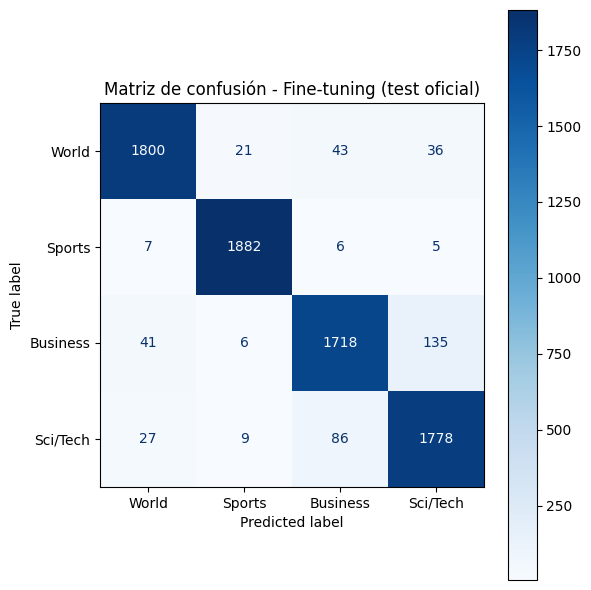

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ["World", "Sports", "Business", "Sci/Tech"]

cm = confusion_matrix(test_labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Fine-tuning (test oficial)")
plt.tight_layout()
plt.show()

In [47]:
import torch
import torch.nn.functional as F
import pandas as pd

# Probabilidades y confianza del modelo para cada predicción
logits = torch.tensor(predictions.predictions)
probs = F.softmax(logits, dim=1).numpy()
confidence = probs.max(axis=1)

# Texto original (antes de tokenizar) para poder leer los ejemplos
raw_test_texts = dataset["test"]["text"]

errors_df = pd.DataFrame({
    "text": raw_test_texts,
    "true_label": [class_names[l] for l in test_labels],
    "predicted_label": [class_names[l] for l in predicted_labels],
    "confidence": confidence
})

errors_df = errors_df[errors_df["true_label"] != errors_df["predicted_label"]]
errors_df = errors_df.sort_values("confidence", ascending=False)

print(f"Total de errores: {len(errors_df)} de {len(test_labels)} ejemplos de test "
      f"({len(errors_df) / len(test_labels):.2%})")

pd.set_option("display.max_colwidth", 120)
errors_df.head(15)

Total de errores: 422 de 7600 ejemplos de test (5.55%)


,text,true_label,predicted_label,confidence
912,Bryant Makes First Appearance at Trial (AP) AP - NBA star Kobe Bryant arrived at his sexual assault trial Monday as ...,Sci/Tech,Sports,0.999841
3077,Brewers buyer expected to step out of the shadows Monday MILWAUKEE - Paul Attanasio says the story of his brother bu...,Business,Sports,0.999372
120,"Oil prices bubble to record high The price of oil has continued its sharp rise overnight, closing at a record high. ...",World,Business,0.998679
6185,Special to ESPN.com It #39;s the age old question: quot;What do you give to the man who #39;s been everything? quot...,Business,Sports,0.998618
5127,Another homicide in Holland It is a sad day. In what seems to be another politically inspired homicide in Holl...,Sci/Tech,World,0.998596
1197,World briefs LONDON - A man wielding a machete and a knife attacked two security guards at the building housing the ...,Business,World,0.998586
311,"French Take Gold, Bronze in Single Kayak ATHENS, Greece - Winning on whitewater runs in the family for Frenchman Ben...",Sports,World,0.998556
5841,"INSIDE INFO: Man Utd shares drop MAN UNITED #39;S share price has fallen by just over 2.5, less than expected after ...",Sports,Business,0.998430
3688,"Ljubicic Downs Hanescu at Open De Moselle Top-seeded Ivan Ljubicic of Croatia beat Victor Hanescu of Romania 6-4, 6-...",World,Sports,0.998403
2833,Man arrested for fatally stabbing elderly parents SAITAMA -- A middle-aged man who fatally stabbed his parents has b...,Sci/Tech,World,0.998332


In [48]:
# Pares de confusión más frecuentes (etiqueta verdadera -> predicha)
print("Errores por clase verdadera:")
print(errors_df["true_label"].value_counts())
print()
print("Confusiones más frecuentes:")
print(
    errors_df.groupby(["true_label", "predicted_label"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

Errores por clase verdadera:
true_label
Business    182
Sci/Tech    122
World       100
Sports       18
Name: count, dtype: int64

Confusiones más frecuentes:
true_label  predicted_label
Business    Sci/Tech           135
Sci/Tech    Business            86
World       Business            43
Business    World               41
World       Sci/Tech            36
Sci/Tech    World               27
World       Sports              21
Sci/Tech    Sports               9
Sports      World                7
Business    Sports               6
dtype: int64


### Interpretación

- Par de clases que más se confunde entre sí: **Business ↔ Sci/Tech** (Business→Sci/Tech: 135 casos, Sci/Tech→Business: 86 casos). Es la confusión dominante, probablemente porque muchas noticias de tecnología corporativa (ej. resultados financieros de empresas tech, fusiones, IPOs) tienen vocabulario y contexto que se solapan entre ambas categorías.
- Segunda confusión más frecuente: **World ↔ Business** (World→Business: 43, Business→World: 41), posiblemente por noticias de economía internacional o política que involucra empresas.
- Total de errores en el test oficial: **422 de 7,600 ejemplos (5.55%)**.
- La clase con más errores en términos absolutos es **Business** (182 errores), mientras que **Sports** es la más robusta (solo 18 errores), consistente con que "Sports" tiene un vocabulario mucho más distintivo y menos ambigüedad temática que las otras tres categorías.

In [49]:
# Guardar modelo fine-tuned y tokenizer
model.save_pretrained("./bert_agnews_final")
tokenizer.save_pretrained("./bert_agnews_final")

print("Modelo y tokenizer guardados correctamente.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo y tokenizer guardados correctamente.


In [50]:
import os

print(os.listdir("./bert_agnews_final"))

['model.safetensors', 'config.json', 'tokenizer_config.json', 'tokenizer.json']


In [51]:
from huggingface_hub import notebook_login

notebook_login()  # pega tu token de Hugging Face (con permiso de escritura) cuando se te pida

In [52]:
from huggingface_hub import HfApi

# TODO: reemplaza por tu usuario u organización de Hugging Face
HF_USERNAME = "bialexacosta21"
repo_id = f"{HF_USERNAME}/bert-agnews-topic-classification"

model.push_to_hub(repo_id)
tokenizer.push_to_hub(repo_id)

print("Modelo y tokenizer subidos a:", f"https://huggingface.co/{repo_id}")

README.md:   0%|          | 0.00/1.90k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...fgglfr2/model.safetensors:   0%|          | 14.2kB /  438MB            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Modelo y tokenizer subidos a: https://huggingface.co/bialexacosta21/bert-agnews-topic-classification


In [53]:
model_card = f"""---
language: en
license: apache-2.0
tags:
- text-classification
- bert
- ag-news
datasets:
- fancyzhx/ag_news
metrics:
- accuracy
- f1
---

# BERT fine-tuned on AG News (Topic Classification)

## Model description

This model is a fine-tuned version of `bert-base-uncased` for topic classification on the AG News dataset. It classifies English news articles into four categories: World, Sports, Business, and Sci/Tech.

## Training data

- Dataset: [fancyzhx/ag_news](https://huggingface.co/datasets/fancyzhx/ag_news)
- Training examples: {len(train_dataset)} (after reserving {len(validation_dataset)} for validation)
- Validation examples: {len(validation_dataset)}
- Test examples (official, held out for final evaluation only): {len(test_dataset)}
- Classes: World, Sports, Business, Sci/Tech

## Training procedure

- Base model: `bert-base-uncased`
- Adaptation method: Full fine-tuning
- Encoder learning rate: 2e-5
- Classification head learning rate: 1e-3
- Train batch size: 16, eval batch size: 32
- Epochs: 1
- Seed: 42

## Evaluation results (official AG News test set)

- Accuracy: {{accuracy_ft:.4f}}
- Macro F1: {{macro_f1_ft:.4f}}
- Eval loss: {{eval_results['eval_loss']:.4f}}

## Intended use

Automatic topic classification of English news articles into the four AG News categories. Can serve as a baseline for organizing or filtering English news content by topic.

## Limitations

- Trained and evaluated only on AG News; may not generalize to other domains, writing styles, or languages.
- English only.
- Input truncated to 128 tokens.
- Fine-tuned for a single epoch.

## References

- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.
- Zhang, X., Zhao, J., & LeCun, Y. (2015). Character-level Convolutional Networks for Text Classification (source of the AG News corpus).
- Hugging Face Transformers documentation: https://huggingface.co/docs/transformers
"""

with open("./bert_agnews_final/README.md", "w") as f:
    f.write(model_card)

api = HfApi()
api.upload_file(
    path_or_fileobj="./bert_agnews_final/README.md",
    path_in_repo="README.md",
    repo_id=repo_id,
    repo_type="model"
)

print("Model Card subido a", f"https://huggingface.co/{repo_id}")

No files have been modified since last commit. Skipping to prevent empty commit.


Model Card subido a https://huggingface.co/bialexacosta21/bert-agnews-topic-classification


In [54]:
# Verificación: el modelo publicado se puede descargar y cargar correctamente
from transformers import AutoTokenizer, AutoModelForSequenceClassification

check_tokenizer = AutoTokenizer.from_pretrained(repo_id)
check_model = AutoModelForSequenceClassification.from_pretrained(repo_id)

print("Carga exitosa desde Hugging Face Hub:", repo_id)
print("Número de clases:", check_model.config.num_labels)

config.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Carga exitosa desde Hugging Face Hub: bialexacosta21/bert-agnews-topic-classification
Número de clases: 4


**URL del repositorio para compartir con el equipo:** `https://huggingface.co/bialexacosta21/bert-agnews-topic-classification'

# Comparación de métodos

| Método | Modelo | Accuracy | F1 Macro | Tiempo de entrenamiento |
|---|---|---:|---:|---:|
| Feature-based | BERT congelado + Logistic Regression | 0.9036 | 0.90 | 222.54 s |
| Fine-tuning | BERT + Classification Head | 0.9445 | 0.9444 | 2531.99 s |

## Conclusión

El enfoque Feature-based alcanzó una accuracy de 90.36% y un F1 Macro de 0.90 utilizando BERT como extractor de características con el encoder congelado y un clasificador de Logistic Regression.

El enfoque Fine-tuning alcanzó una accuracy de 94.45% y un F1 Macro de 0.9444, superando al enfoque Feature-based en este experimento. La mejora fue de aproximadamente 4.09 puntos porcentuales de accuracy y 0.04 puntos en F1 Macro.

Sin embargo, Fine-tuning requirió un tiempo de entrenamiento considerablemente mayor: 2531.99 segundos frente a 222.54 segundos del enfoque Feature-based.

Considerando el objetivo de maximizar el desempeño de clasificación, se selecciona el modelo Fine-tuned como modelo final para la tarea de Topic Classification. El enfoque Feature-based se mantiene como alternativa válida cuando se requiere reducir el costo computacional y el tiempo de entrenamiento.

# Final Model Documentation

## Task

Topic Classification on AG News.

## Dataset

- Dataset: `fancyzhx/ag_news`
- Training examples: 108,000
- Validation examples: 12,000
- Test examples: 7,600
- Number of classes: 4
- Classes: World, Sports, Business, Sci/Tech
- Maximum sequence length: 128 tokens

## Methods Compared

### Method 1 — Feature-based Adaptation

- Base model: `bert-base-uncased`
- BERT encoder frozen
- Feature representation: `[CLS]` embedding with 768 dimensions
- Classifier: Logistic Regression
- Accuracy: 90.36%
- Macro F1: 0.90
- Training time: 222.54 seconds

### Method 2 — Fine-tuning

- Base model: `bert-base-uncased`
- BERT encoder fine-tuned
- Classification head with 4 output classes
- Encoder learning rate: `2e-5`
- Classification head learning rate: `1e-3`
- Training batch size: 16
- Evaluation batch size: 32
- Number of epochs: 1
- Training steps: 6,750
- Seed: 42
- Accuracy: 94.45%
- Macro F1: 0.9444
- Evaluation loss (official test set): 0.1754
- Total training time: 2531.99 seconds

## Final Model

The fine-tuned BERT model was selected as the final model for Topic Classification because it achieved higher classification performance than the Feature-based approach in this experiment.

The final model achieved 94.45% accuracy and a Macro F1-score of 0.9444 on the AG News official test set.

## Intended Use

This model is intended for automatic topic classification of English news articles into four categories:

- World
- Sports
- Business
- Sci/Tech

It can be used as a baseline system for automatically organizing or categorizing English news content by topic.

## Limitations

- The model was trained and evaluated only on the AG News dataset.
- It is designed for English text.
- Performance may decrease on news articles from different domains, writing styles, or data distributions.
- Input sequences are limited to 128 tokens, so longer texts are truncated.
- Only one training epoch was used for the fine-tuning experiment.
- 10% of the original training set was held out as a validation split, used only to monitor training; the official test set was kept fully separate and used exclusively for final evaluation.
- The reported performance reflects the specific training configuration and dataset used in this experiment.

## Reproducibility

- Base model: `bert-base-uncased`
- Dataset: `fancyzhx/ag_news`
- Maximum sequence length: 128
- Training batch size: 16
- Evaluation batch size: 32
- Encoder learning rate: `2e-5`
- Classification head learning rate: `1e-3`
- Number of epochs: 1
- Training/validation split: 90% / 10% (seed=42)
- Training steps: 6,750
- Seed: 42

## Model on Hugging Face Hub

https://huggingface.co/bialexacosta21/bert-agnews-topic-classification

## References

- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. NAACL-HLT.
- Zhang, X., Zhao, J., & LeCun, Y. (2015). Character-level Convolutional Networks for Text Classification (source of the AG News corpus). NeurIPS.
- Hugging Face Transformers documentation: https://huggingface.co/docs/transformers
- AG News dataset card: https://huggingface.co/datasets/fancyzhx/ag_news